# Aula 12 - Aprendizado Não Supervisionado - Parte 1 (Agrupamento K-Means & Escolha do K)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Ao longo de todo o Bloco 2, trabalhamos com Aprendizado Supervisionado (onde sempre fornecíamos o rótulo $y$). Agora, entramos no universo Não Supervisionado, onde o objetivo é descobrir estruturas ocultas, padrões e agrupamentos naturais nos dados sem nenhuma intervenção humana prévia.
> 🎯 **Objetivo Principal da Aula:** Dominar o algoritmo de clusterização **K-Means**, compreender o cálculo iterativo de centroides euclidianos, e aplicar critérios matemáticos para definir o número ideal de grupos $K$ utilizando o **Método do Cotovelo (Elbow Method / WCSS)** e o **Coeficiente de Silhueta**.
> 🚀 **Para onde vamos:** Na próxima aula ('Aprendizado Não Supervisionado - Parte 2'), veremos o que fazer quando o K-Means falha: quando os grupos têm formatos geométricos complexos (meias-luas, anéis) ou quando queremos construir uma árvore genealógica de dados com **Agrupamento Hierárquico** e **DBSCAN**.

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & Aprendizado Não Supervisionado** | Dados sem rótulos ($y$), o conceito de *Clustering* / Agrupamento e a intuição iterativa do K-Means. |
| **Módulo 2** | **Métricas de Avaliação de Cluster: Inércia vs Silhueta** | A Inércia (WCSS — Soma dos Erros Quadráticos) e a Coeficiente de Silhueta. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 7 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Segmentação de perfil de clientes com alteração da quantidade de clusters $K$. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & O Paradigma Não Supervisionado

### 1.1 O que muda sem os Rótulos ($y$)?
No Aprendizado Não Supervisionado, o conjunto de dados contém **apenas os atributos ($X$)**, sem nenhum rótulo ou gabarito!

O objetivo do algoritmo é analisar a **geometria e semelhança dos dados** para agrupar amostras parecidas em clusters (*Segmentação de Mercado*, *Sistemas de Recomendação*, *Detecção de Anomalias*).

### 1.2 O Algoritmo K-Means em 4 Passos Iterativos

```mermaid
graph TD
    P1["Passo 1: Seleciona K pontos aleatórios como CENTROIDES iniciais"] --> P2["Passo 2: Atribui cada amostra ao centroide mais próximo (Distância Euclidiana)"]
    P2 --> P3["Passo 3: Recalcula a posição de cada centroide (Média das coordenadas)"]
    P3 --> P4["Passo 4: Repete Passos 2 e 3 até a CONVERGÊNCIA TOTAL!"]
```

> [!TIP]
> 🏰 **Analogia Geek — Segmentação de Guildas / Facções em um MMO:**
> Imagine milhares de jogadores em um MMORPG (World of Warcraft / Guild Wars). O **K-Means** analisa a posição geográfica dos jogadores no mapa e seu estilo de jogo, agrupando-os automaticamente em 4 **Guildas (Clusters)** sem que ninguém precise dizer quem pertence a qual facção! Os **Centroides** são como os líderes de cada guilda posicionados no centro do seu território!

> [!NOTE]
> 💡 **Curiosidade da Aula — Hugo Steinhaus & Bell Labs:**
> A ideia original do K-Means foi proposta pelo matemático polonês **Hugo Steinhaus em 1956**. No entanto, a versão computacional mais famosa foi criada por **Stuart Lloyd na Bell Labs em 1957** para converter sinais de áudio analógicos em pulsos digitais! O algoritmo de Lloyd é o coração do K-Means do Scikit-Learn até hoje!  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O Aprendizado Não Supervisionado encontra agrupamentos naturais em dados sem rótulos ($X$), e o K-Means posiciona K centroides geométricos iterativamente para definir cada grupo.

---

## Módulo 2: O Mecanismo por Dentro & Escolha do número de Clusters $K$

### 2.1 Como saber qual é o melhor valor de $K$?

1. **Método do Cotovelo (Elbow Method):** Plotamos o gráfico da **Inércia (WCSS)** para $K=1$ a $K=10$ e procuramos a "dobra" do cotovelo.
2. **Coeficiente de Silhueta (Silhouette Score):** Mede a coesão interna e separação dos clusters (variação de $-1.0$ a $+1.0$).

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O Método do Cotovelo identifica a quantidade ideal de grupos no ponto de inflexão da inércia, enquanto o Coeficiente de Silhueta confirma se os grupos estão bem separados uns dos outros.

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** aqui não há uma coluna de resposta certa. O K-Means procura grupos parecidos por conta própria. Primeiro veja os pontos, depois os grupos criados e, por fim, os gráficos que ajudam a escolher `K`. O objetivo é interpretar a organização visual, não decorar fórmulas.

---

### Bloco 3.1 — Gerando Dados Sintéticos para Agrupamento (`make_blobs`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é a função `make_blobs`?**  
> É um utilitário do Scikit-Learn que gera "bolhas" (clusters) geométricas no plano cartesiano para que possamos testar algoritmos de agrupamento em um ambiente controlado.

In [1]:
# 1. Importamos as bibliotecas de dados, gráficos e clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# 2. Geramos um dataset sintético com 300 pontos e 4 grupos geométricos reais
matriz_pontos_sinteticos, vetor_grupos_reais = make_blobs(
    n_samples=300, 
    centers=4, 
    cluster_std=0.7, 
    random_state=42
)

# 3. Exibimos a dimensão do dataset gerado
print("--- DATASET SINTÉTICO GERADO ---")
print(f"📐 Dimensão da Matriz X: {matriz_pontos_sinteticos.shape} (300 amostras, 2 atributos)")

--- DATASET SINTÉTICO GERADO ---
📐 Dimensão da Matriz X: (300, 2) (300 amostras, 2 atributos)


---

### Bloco 3.2 — Executando o Algoritmo K-Means com $K=4$

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que faz a função `.fit_predict()` no K-Means?**  
> Ela calcula a posição ideal dos K centroides (`fit`) e já retorna o vetor com o número do cluster ($0, 1, 2, 3$) atribuído a cada uma das 300 amostras (`predict`).

In [2]:
# 1. Instanciamos o K-Means definindo K=4 clusters e 10 inicializações (n_init=10)
modelo_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. O MOMENTO DO AGRUPAMENTO: O algoritmo calcula centroides e rotula os pontos
rotulos_clusters_kmeans = modelo_kmeans.fit_predict(matriz_pontos_sinteticos)

# 3. Exibimos os primeiros 10 rótulos atribuídos no console
print("--- CLUSTERS ATRIBUÍDOS PELO K-MEANS ---")
print("Primeiros 10 rótulos de clusters atribuídos pela IA:")
print(rotulos_clusters_kmeans[:10])

--- CLUSTERS ATRIBUÍDOS PELO K-MEANS ---
Primeiros 10 rótulos de clusters atribuídos pela IA:
[3 3 0 1 3 1 2 1 0 2]


---

### Bloco 3.3 — Extraindo as Coordenadas dos Centroides (`cluster_centers_`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que representa a matriz `.cluster_centers_`?**  
> Representa as coordenadas $(X, Y)$ exatas dos pontos centrais (líderes) calculados para cada um dos K grupos.

In [3]:
# 1. Extraímos as coordenadas dos 4 centroides calculados
coordenadas_centroides = modelo_kmeans.cluster_centers_

# 2. Exibimos as coordenadas dos centroides no console
print("--- COORDENADAS DOS 4 CENTROIDES LOCALIZADOS ---")
print(coordenadas_centroides.round(2))

--- COORDENADAS DOS 4 CENTROIDES LOCALIZADOS ---
[[-2.62  8.99]
 [-6.85 -6.85]
 [ 4.69  2.02]
 [-8.83  7.23]]


---

### Bloco 3.4 — Plotando os Clusters e Centroides (Gráfico Seaborn)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como destacamos os centroides no gráfico?**  
> Desenhamos primeiro os 300 pontos com `sns.scatterplot` e depois usamos `plt.scatter` com `marker='X'` e tamanho grande (`s=250`) em vermelho para colocar os Xis do centroide por cima.

🎨 Exibindo os clusters e centroides no Colab...


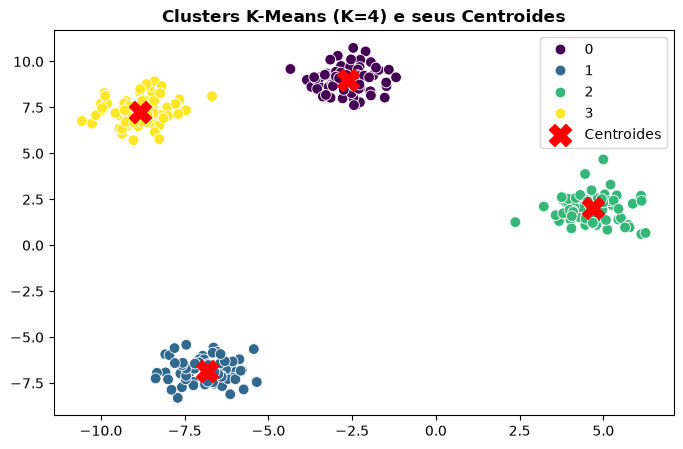

In [4]:
# 1. Definimos as dimensões do gráfico
plt.figure(figsize=(8, 5))

# 2. Plotamos os 300 pontos coloridos pelo cluster atribuído
sns.scatterplot(
    x=matriz_pontos_sinteticos[:, 0], 
    y=matriz_pontos_sinteticos[:, 1], 
    hue=rotulos_clusters_kmeans, 
    palette='viridis', 
    s=60
)

# 3. Sobrepomos as marcações dos 4 centroides em vermelho com símbolo 'X'
plt.scatter(
    coordenadas_centroides[:, 0], 
    coordenadas_centroides[:, 1], 
    color='red', 
    marker='X', 
    s=250, 
    label='Centroides'
)

# 4. Adicionamos os títulos e legenda ao gráfico
plt.title("Clusters K-Means (K=4) e seus Centroides", fontweight='bold')
plt.legend()

# 5. Renderizamos a imagem no notebook
print("🎨 Exibindo os clusters e centroides no Colab...")
plt.show()

---

### Bloco 3.5 — Calculando o Método do Cotovelo (*Elbow Method*)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é a Inércia (WCSS)?**  
> É a soma das distâncias ao quadrado entre os pontos e os seus respectivos centroides. Quanto mais alto o valor de K, menor a inércia. O ideal é encontrar o ponto onde a queda da inércia deixa de ser drástica (o "cotovelo").

In [5]:
# 1. Criamos a lista vazia para armazenar as inércias de cada K
lista_inercias_wcss = []
faixa_testes_k = range(1, 11)

# 2. Testamos K variando de 1 a 10 e armazenamos o atributo .inertia_
for k_atual in faixa_testes_k:
    km_teste = KMeans(n_clusters=k_atual, random_state=42, n_init=10)
    km_teste.fit(matriz_pontos_sinteticos)
    lista_inercias_wcss.append(km_teste.inertia_)

# 3. Exibimos os valores de inércia calculados
print("--- CÁLCULO DA INÉRCIA PARA O MÉTODO DO COTOVELO ---")
print("Valores de Inércia calculados:", [round(inercia, 1) for inercia in lista_inercias_wcss])

--- CÁLCULO DA INÉRCIA PARA O MÉTODO DO COTOVELO ---
Valores de Inércia calculados: [19710.6, 9125.8, 1840.9, 277.5, 251.0, 225.6, 200.4, 178.2, 160.5, 142.2]


---

### Bloco 3.6 — Plotando o Gráfico do Cotovelo

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Onde fica o "cotovelo" no gráfico?**  
> Fica exatamente na dobradiça da linha. Repare que de K=1 para K=4 a inércia despenca vertiginosamente. A partir de K=4, a queda vira uma rampa quase plana. Logo, **K=4 é a escolha ideal**!

🎨 Exibindo o gráfico do cotovelo no Colab...


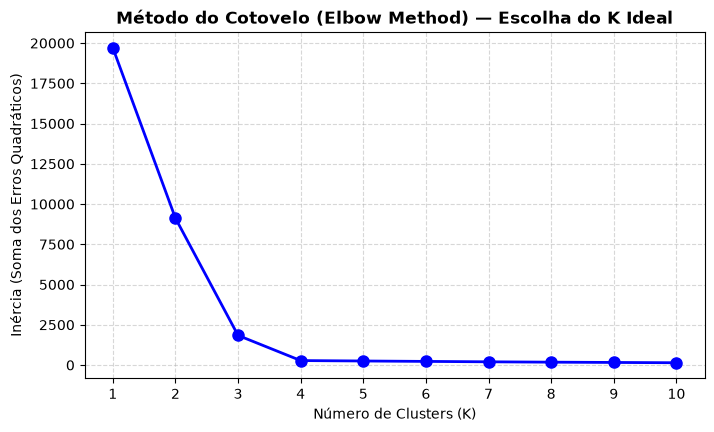

In [6]:
# 1. Definimos o tamanho da figura do gráfico
plt.figure(figsize=(8, 4.5))

# 2. Desenhamos a linha azul com pontos circulares mostrando a queda da inércia
plt.plot(faixa_testes_k, lista_inercias_wcss, 'bo-', linewidth=2, markersize=8)

# 3. Adicionamos rótulos aos eixos e à grade
plt.title("Método do Cotovelo (Elbow Method) — Escolha do K Ideal", fontweight='bold')
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia (Soma dos Erros Quadráticos)")
plt.xticks(faixa_testes_k)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Exibimos o gráfico no notebook
print("🎨 Exibindo o gráfico do cotovelo no Colab...")
plt.show()

---

### Bloco 3.7 — Avaliando o Coeficiente de Silhueta (`silhouette_score`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que indica a pontuação de Silhueta?**  
> Mede a qualidade do agrupamento em uma escala de $-1.0$ a $+1.0$. Valores acima de $0.50$ indicam que os clusters estão muito bem definidos e isolados uns dos outros.

In [7]:
# 1. Calculamos o Coeficiente de Silhueta comparando os pontos com o agrupamento K=4
pontuacao_silhueta = silhouette_score(matriz_pontos_sinteticos, rotulos_clusters_kmeans)

# 2. Exibimos a pontuação obtida
print("--- MÉTRICA DE SILHUETA CALCULADA ---")
print(f"📊 Coeficiente de Silhueta para K=4: {pontuacao_silhueta:.4f} (Excelente coesão e separação!)")

--- MÉTRICA DE SILHUETA CALCULADA ---
📊 Coeficiente de Silhueta para K=4: 0.8546 (Excelente coesão e separação!)


---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere o código de segmentação de clientes abaixo para testar diferentes números de clusters $K$:

1. **Altere a quantidade de clusters $K$:** Na linha `quantidade_k_escolhida = 3`, experimente alterar para `2`, `4` ou `5`.
2. **Re-execute e observe:** Veja como a pontuação de Silhueta muda e como os centroides se reposicionam no gráfico!

--- SEU TESTE PERSONALIZADO (K = 3) ---
📊 Coeficiente de Silhueta Obtido: 0.7100


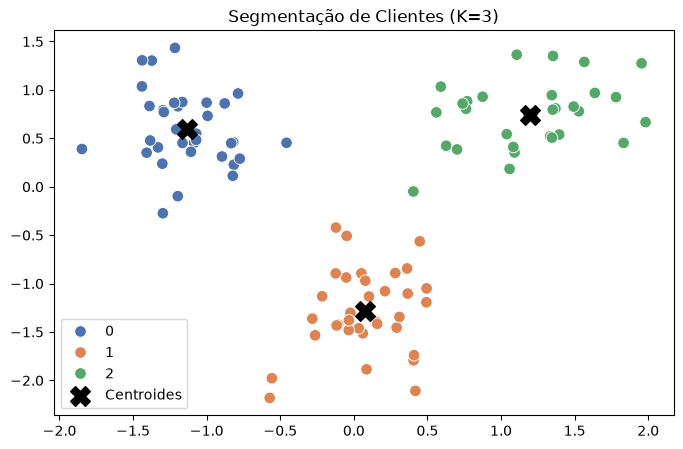

In [8]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Geramos dataset sintético simulado de perfil de gastos de clientes
np.random.seed(66)
n = 100
renda_anual_k = np.concatenate([np.random.normal(30, 8, 35), np.random.normal(70, 10, 35), np.random.normal(110, 12, 30)])
score_gastos = np.concatenate([np.random.normal(80, 10, 35), np.random.normal(40, 10, 35), np.random.normal(85, 8, 30)])

tabela_loja = pd.DataFrame({'renda_k': renda_anual_k, 'score_gastos': score_gastos})
matriz_loja_padronizada = StandardScaler().fit_transform(tabela_loja.values)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE A QUANTIDADE DE CLUSTERS K:
# -----------------------------------------------------------------------------
quantidade_k_escolhida = 3 # Tente mudar para 2, 4 ou 5 e veja o resultado!

# 2. Instanciamos o K-Means com o K selecionado pelo estudante
kmeans_estudante = KMeans(n_clusters=quantidade_k_escolhida, random_state=66, n_init=10)
rotulos_estudante = kmeans_estudante.fit_predict(matriz_loja_padronizada)
pontuacao_silhueta_estudante = silhouette_score(matriz_loja_padronizada, rotulos_estudante)

# 3. Exibimos a pontuação obtida
print(f"--- SEU TESTE PERSONALIZADO (K = {quantidade_k_escolhida}) ---")
print(f"📊 Coeficiente de Silhueta Obtido: {pontuacao_silhueta_estudante:.4f}")

# 4. Desenhamos o gráfico de dispersão com os centroides
plt.figure(figsize=(8, 5))
sns.scatterplot(x=matriz_loja_padronizada[:, 0], y=matriz_loja_padronizada[:, 1], hue=rotulos_estudante, palette='deep', s=70)
plt.scatter(kmeans_estudante.cluster_centers_[:, 0], kmeans_estudante.cluster_centers_[:, 1], color='black', marker='X', s=200, label='Centroides')
plt.title(f"Segmentação de Clientes (K={quantidade_k_escolhida})")
plt.legend()
plt.show()

---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — O que fazer quando os grupos não são círculos perfeitos?**  
> O K-Means assume que todos os grupos são 'bolhas redondas'. Mas se os dados formarem formatos de meia-lua, espirais ou estradas sinuosas, o K-Means corta os grupos no meio e erra feio! Na **Aula 13**, conheceremos o **DBSCAN** (que agrupa por densidade de vizinhos e ignora ruídos) e o **Agrupamento Hierárquico** (que desenha um lindo *Dendrograma* mostrando a união progressiva dos dados).
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Como um algoritmo baseado em densidade pode ser usado por um banco para detectar compras fraudulentas no cartão de crédito? (Dica: o que acontece com transações isoladas onde não há vizinhos por perto?)

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi a diferença entre Aprendizado Supervisionado e Não Supervisionado.
- [ ] Sei implementar o algoritmo K-Means usando `sklearn.cluster.KMeans`.
- [ ] Entendi como localizar e interpretar as coordenadas dos centroides.
- [ ] Dominei o Método do Cotovelo para encontrar o $K$ ótimo observando a Inércia.
- [ ] Sei alterar o valor de $K$ no script e analisar o gráfico resultante.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 9: K-Means).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 12: Clusterização K-Means e Seleção do K Ideal

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Wine Recognition Dataset* (Dados químicos sem rótulos supervisionados)

---

## 🎯 Objetivo do Laboratório
Realizar a segmentação e descoberta de grupos naturais em dados multidimensionais: aplicar padronização obrigatória com `StandardScaler`, calcular a Inércia (WCSS) para $K=1..8$, plotar o **Gráfico do Cotovelo (*Elbow Plot*)**, calcular o **Coeficiente de Silhueta** e visualizar a distribuição dos clusters e centroides.

---

### Passo 1 — Preparando Dados Reais sem Gabarito ($y$)

In [9]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Carregamos o dataset e ignoramos totalmente os rótulos de classe
dados_vinho = load_wine(as_frame=True)
X_bruto = dados_vinho.data

# 2. A padronização é obrigatória para que variáveis de escalas grandes não dominem a distância
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

print(f"Matriz de dados para agrupamento não supervisionado: {X_scaled.shape}")

Matriz de dados para agrupamento não supervisionado: (178, 13)


---

### Passo 2 — Cálculo do Método do Cotovelo (*Elbow Method*)

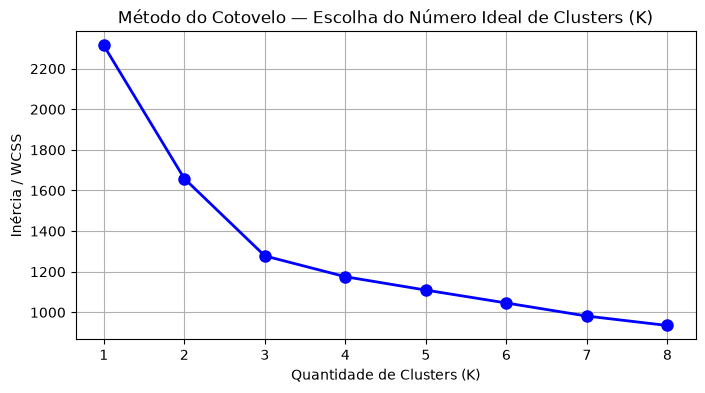

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
valores_k = range(1, 9)

# 1. Calculamos o WCSS (Soma dos Quadrados Intra-Cluster) de 1 a 8 grupos
for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(X_scaled)
    inercia.append(kmeans_teste.inertia_)

# 2. Plotamos o Gráfico do Cotovelo
plt.figure(figsize=(8, 4))
plt.plot(valores_k, inercia, 'bo-', linewidth=2, markersize=8)
plt.title("Método do Cotovelo — Escolha do Número Ideal de Clusters (K)")
plt.xlabel("Quantidade de Clusters (K)")
plt.ylabel("Inércia / WCSS")
plt.grid(True)
plt.show()

---

### Passo 3 — Validação com Coeficiente de Silhueta

In [11]:
from sklearn.metrics import silhouette_score

# 1. Calculamos a silhueta para K de 2 a 6
for k in range(2, 7):
    modelo_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo_km.fit_predict(X_scaled)
    score_silhueta = silhouette_score(X_scaled, labels)
    print(f"K = {k} | Coeficiente de Silhueta Médio: {score_silhueta:.4f}")

K = 2 | Coeficiente de Silhueta Médio: 0.2593
K = 3 | Coeficiente de Silhueta Médio: 0.2849
K = 4 | Coeficiente de Silhueta Médio: 0.2602
K = 5 | Coeficiente de Silhueta Médio: 0.2016
K = 6 | Coeficiente de Silhueta Médio: 0.2372


---

### Passo 4 — Treinamento Final e Inspeção dos Clusters

In [12]:
# 1. Executamos o K-Means com K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
grupos_atribuidos = kmeans_final.fit_predict(X_scaled)

# 2. Contamos quantos vinhos foram alocados em cada cluster
df_resultado = pd.DataFrame({'Cluster': grupos_atribuidos})
print("--- DISTRIBUIÇÃO DOS VINHOS POR CLUSTER ---")
print(df_resultado['Cluster'].value_counts())

--- DISTRIBUIÇÃO DOS VINHOS POR CLUSTER ---
Cluster
0    65
2    62
1    51
Name: count, dtype: int64


---

## 🏆 Desafio Técnico de Validação
Verifique a matriz de centroides (`kmeans_final.cluster_centers_`) e descubra qual cluster possui o maior valor médio padronizado para o primeiro atributo químico (`alcohol`).

In [13]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
